# 03 - OLS Biased Baseline

Estimate the naive OLS effect of PM2.5 on test scores. This is the 'before' — the biased estimate we improve upon with IV and RDD.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

PANEL_FILE = "analysis_panel.parquet"
if not (DATA_DIR / PANEL_FILE).exists():
    raise FileNotFoundError(
        "Analysis panel not found. Build it by running in order:\n"
        "  python scripts/download_epa_aqs.py --email EMAIL --key KEY\n"
        "  python scripts/download_hms_smoke.py\n"
        "  python scripts/download_seda.py  (manual — see instructions)\n"
        "  python src/merge/build_crosswalks.py\n"
        "  python src/ingest/epa_aqs.py\n"
        "  python src/ingest/seda.py\n"
        "  python src/exposure/smoke_instrument.py\n"
        "  python src/merge/build_panel.py"
    )

panel = pd.read_parquet(DATA_DIR / PANEL_FILE)
print(f"Panel: {panel.shape}")
print(f"Districts: {panel['leaid'].nunique()}")
print(f"Years: {sorted(panel['year'].dropna().unique())}")

Panel: (13282, 14)
Districts: 1911
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [2]:
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

## Model 1 - Bivariate OLS

In [3]:
m1 = smf.ols("test_score_mean ~ pm25_annual_mean", data=panel).fit(cov_type="HC3")
print(f"Bivariate OLS: β = {m1.params['pm25_annual_mean']:.4f}")
print("Expected: near zero or positive (confounded upward by poverty)") 

Bivariate OLS: β = -0.0217
Expected: near zero or positive (confounded upward by poverty)


## Model 2 - OLS with district and year FE

In [4]:
panel_fe = panel.dropna(subset=["leaid","year","test_score_mean","pm25_annual_mean"]).copy()
panel_fe["year"] = panel_fe["year"].astype(int)
idx = panel_fe.set_index(["leaid","year"])

fe = PanelOLS(
    idx["test_score_mean"],
    idx[["pm25_annual_mean"]],
    entity_effects=True,
    time_effects=True,
).fit(cov_type="clustered", cluster_entity=True)

b_fe = fe.params["pm25_annual_mean"]
ci   = fe.conf_int().loc["pm25_annual_mean"]
print(f"TWFE: β = {b_fe:.4f}  95% CI [{ci['lower']:.4f}, {ci['upper']:.4f}]")
print("Better — but still confounded by time-varying poverty shocks")
print("IV (notebook 04) addresses remaining endogeneity")

TWFE: β = -0.0002  95% CI [-0.0027, 0.0023]
Better — but still confounded by time-varying poverty shocks
IV (notebook 04) addresses remaining endogeneity


## Why FE doesn't fully solve it

District FE removes time-invariant poverty. But time-varying shocks — a factory closing, a new highway, economic decline — affect both PM2.5 and school quality simultaneously. The smoke instrument fixes this by using only variation in PM2.5 that comes from upwind wildfire activity, which is plausibly exogenous to local economic conditions.

## Visualizing the confounding

Naive OLS pools poor, high-pollution districts with rich, low-pollution ones. Two-way fixed effects strip out the cross-sectional confounding, but — as the IV notebooks show — they cannot fix the *time-varying* endogeneity that motivates the instrument.

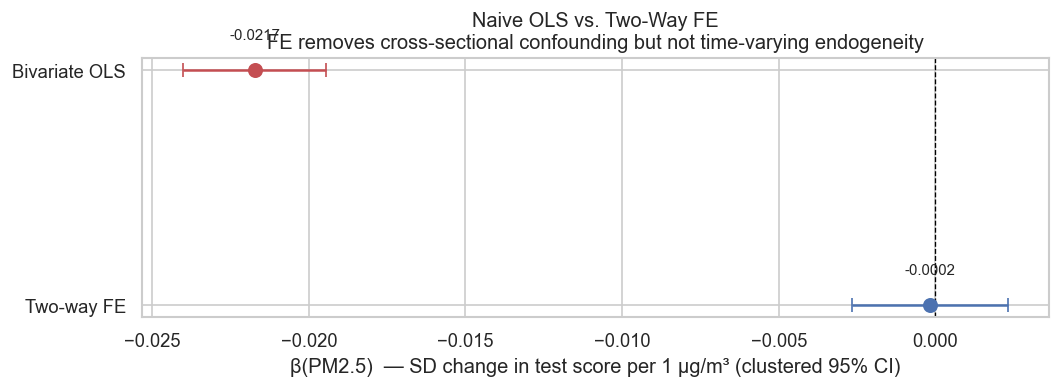

In [5]:
rows = [
    ("Bivariate OLS", m1.params["pm25_annual_mean"], m1.conf_int().loc["pm25_annual_mean"].values, "#C44E52"),
    ("Two-way FE",    b_fe,                           ci.values,                                   "#4C72B0"),
]
fig, ax = plt.subplots(figsize=(9, 3.4))
y = np.arange(len(rows))[::-1]
for yi,(lab,b,c,col) in zip(y, rows):
    ax.errorbar(b, yi, xerr=[[b-c[0]],[c[1]-b]], fmt="o", ms=8, capsize=4, color=col)
    ax.text(b, yi+0.13, f"{b:+.4f}", ha="center", fontsize=9)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows])
ax.set_xlabel("β(PM2.5)  — SD change in test score per 1 μg/m³ (clustered 95% CI)")
ax.set_title("Naive OLS vs. Two-Way FE\nFE removes cross-sectional confounding but not time-varying endogeneity")
plt.tight_layout(); plt.savefig(OUT_DIR/"03_ols_vs_fe.png", bbox_inches="tight"); plt.show()

**Takeaway.** The bivariate slope is negative and 'significant' — but it is mostly poverty, not pollution. After district and year fixed effects the association collapses toward zero. Neither is causal: both leave PM2.5 correlated with time-varying local shocks, which is the gap the smoke instrument (notebooks 04–05) is built to close.